In [1]:
import BECancerResistome
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from matplotlib.lines import Line2D
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, average_precision_score, f1_score
from sklearn.preprocessing import label_binarize, StandardScaler
from sklearn.metrics import precision_recall_curve, average_precision_score
import time
import shap
import optuna
import umap

In [2]:
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

# Load Data

In [3]:
annotated_control_df = pd.read_csv("data/8_Cellular_Drug_Context/zscores-unambiguous-VEPannotated-processed-protvar-cellular_drug_context-control.csv")

In [4]:
annotated_control_df.head()

,Guide,Editor,Gene,Cell_Line,Drug,zscore,Hit_class,Source,Target Transcript ID,uniprot_accession,RefSeq match transcript (MANE Select),Amino Acid Edits,aa_change,Mutation_Category_enc,IMPACT_enc,TSL,SIFT_pathogenicity,PolyPhen_pathogenicity,REVEL,ClinPred,EVE_SCORE,AlphaMissense_score,BayesDel_noAF_score,DANN_score,DEOGEN2_score,ESM1b_score,Eigen-PC-phred_coding,Eigen-PC-raw_coding,GERP++_NR,GERP++_RS,LIST-S2_score,MPC_rankscore,MPC_score,MVP_score,MetaRNN_score,MetaSVM_score,MutFormer_score,MutationAssessor_score,PROVEAN_score,PrimateAI_pred_enc,VARITY_R_LOO_score,bStatistic,fathmm-XF_coding_score,gMVP_score,phastCons100way_vertebrate,phyloP100way_vertebrate,CADD_PHRED,MaxEntScan_alt,MaxEntScan_diff,MaxEntScan_ref,SpliceAI_pred_DP_AG,SpliceAI_pred_DP_AL,SpliceAI_pred_DP_DG,SpliceAI_pred_DP_DL,SpliceAI_pred_DS_AG,SpliceAI_pred_DS_AL,SpliceAI_pred_DS_DG,SpliceAI_pred_DS_DL,BLOSUM62,LOEUF,mutfunc_exp,ada_score,Gene_expression_voom,foldx_ddg,alphafold_plddt,pocket_id,min_pocket_buriedness,pocket_plddt_mean,pocket_score_combined_scaled,CRISPR_essentiality_score,is_in_interface,interface_count,protein_abundance_zscore,gene_cn_total,gene_cn_category_enc,gene_cn_category_Amplification,gene_cn_category_Gain,gene_cn_category_Loss,gene_cn_category_Neutral,lnIC50,drug_target_gene_distance,is_drug_target
0,AAAAAACATCGTAGTAGCAG,CBE,RICTOR,A375,PIC,0.274277,non-hit,EG,ENST00000357387.8,Q6R327,NM_152756.5,His1109Tyr,H1109Y,3.0,2.0,1.0,1.0,0.000,0.214,0.463040,NaN,0.0685,-0.402171,0.970933,0.045001,-4.388,5.314964,0.516773,5.75,5.75,0.917608,0.44121,0.445060,0.093490,0.179100,-1.0259,0.000785,0.345,-0.22,1.0,0.094767,226.0,0.800526,NaN,1.000,5.938,20.400,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,0.305,NaN,NaN,5.531900,NaN,NaN,NaN,NaN,NaN,NaN,-0.243777,0.0,0.0,0.36936,3.0,2.0,0.0,0.0,0.0,1.0,0.311144,2.0,0.0
1,AAAAAACTCAACAGCAGTGA,CBE,NRAS,A375,PIC,0.399691,non-hit,EG,ENST00000369535.5,P01111,NM_002524.5,Leu171Phe,L171F,3.0,2.0,1.0,0.1,NaN,0.141,0.413488,NaN,0.1149,-0.222424,0.993713,0.120039,-5.943,3.683551,0.294249,5.86,5.86,0.865513,0.74516,1.008632,0.619943,0.190982,-0.9613,0.907693,1.385,-1.28,1.0,0.072730,819.0,0.580949,0.628916,1.000,4.055,23.400,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.550,NaN,NaN,6.702081,-0.239753,88.23,NaN,NaN,NaN,NaN,-0.178272,0.0,0.0,-0.61887,3.0,2.0,0.0,0.0,0.0,1.0,0.311144,1.0,0.0
2,AAAAAACTGGCCAGGTGAGC,CBE,PIK3CB,A375,PIC,0.399178,non-hit,EG,ENST00000674063.1,P42338,NM_006219.3,Thr930Ile,T930I,3.0,2.0,NaN,0.0,0.862,NaN,0.373381,NaN,NaN,-0.058094,0.998396,0.879846,-10.191,4.891242,0.469329,5.63,3.78,NaN,0.73854,NaN,NaN,NaN,0.6434,0.529280,3.705,NaN,0.0,0.365695,856.0,0.310513,NaN,0.998,2.094,25.400,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-1.0,0.319,NaN,NaN,5.786491,-0.070749,91.70,10.0,0.848224,90.132188,949.413840,-0.290119,0.0,0.0,0.05922,3.0,2.0,0.0,0.0,0.0,1.0,0.311144,0.0,1.0
3,AAAAAACTGTTTGGGACCTC,CBE,EGFR,A375,PIC,-0.801011,non-hit,EG,ENST00000275493.7,P00533,NM_005228.5,Leu480Leu,L480L,2.0,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9.051,NaN,NaN,NaN,21.0,-44.0,-45.0,45.0,0.0,0.0,0.0,0.0,NaN,0.475,-0.01879,NaN,3.875409,NaN,NaN,6.0,0.808046,94.882812,975.087068,-0.075387,0.0,0.0,-0.74347,3.0,2.0,0.0,0.0,0.0,1.0,0.311144,1.0,0.0
4,AAAAAATCCAGCGTCTAAGC,CBE,MYC,A375,PIC,-0.379377,non-hit,EG,ENST00000621592.8,P01106,NM_002467.6,Asp2Asn,D2N,3.0,2.0,1.0,0.0,0.199,NaN,0.453567,NaN,0.1399,-0.438067,0.984375,NaN,NaN,1.792897,-0.197017,4.31,2.43,0.397160,NaN,NaN,0.733174,0.215208,-0.7405,0.036037,NaN,NaN,1.0,NaN,951.0,0.226082,0.128201,1.000,1.507,22.100,NaN,NaN,NaN,16.0,-14.0,10.0,26.0,0.0,0.0,0.0,0.0,1.0,0.128,NaN,NaN,3.687539,-0.237760,55.70,NaN,NaN,NaN,NaN,-1.698486,0.0,0.0,NaN,3.0,2.0,0.0,0.0,0.0,1.0,0.311144,2.0,0.0


In [23]:
#Keep only EG samples
annotated_variants_df = annotated_control_df[annotated_control_df['Source'] == 'EG']

In [24]:
len(annotated_variants_df)

84024

In [25]:
annotated_variants_df['Cell_Line'].value_counts()

Cell_Line
A375    42012
HT29    42012
Name: count, dtype: int64

In [26]:
annotated_variants_df['Drug'].value_counts()

Drug
PIC    28008
SCH    28008
LIN    28008
Name: count, dtype: int64

# Encode Labels

In [27]:
annotated_variants_df.head()

,Guide,Editor,Gene,Cell_Line,Drug,zscore,Hit_class,Source,Target Transcript ID,uniprot_accession,RefSeq match transcript (MANE Select),Amino Acid Edits,aa_change,Mutation_Category_enc,IMPACT_enc,TSL,SIFT_pathogenicity,PolyPhen_pathogenicity,REVEL,ClinPred,EVE_SCORE,AlphaMissense_score,BayesDel_noAF_score,DANN_score,DEOGEN2_score,ESM1b_score,Eigen-PC-phred_coding,Eigen-PC-raw_coding,GERP++_NR,GERP++_RS,LIST-S2_score,MPC_rankscore,MPC_score,MVP_score,MetaRNN_score,MetaSVM_score,MutFormer_score,MutationAssessor_score,PROVEAN_score,PrimateAI_pred_enc,VARITY_R_LOO_score,bStatistic,fathmm-XF_coding_score,gMVP_score,phastCons100way_vertebrate,phyloP100way_vertebrate,CADD_PHRED,MaxEntScan_alt,MaxEntScan_diff,MaxEntScan_ref,SpliceAI_pred_DP_AG,SpliceAI_pred_DP_AL,SpliceAI_pred_DP_DG,SpliceAI_pred_DP_DL,SpliceAI_pred_DS_AG,SpliceAI_pred_DS_AL,SpliceAI_pred_DS_DG,SpliceAI_pred_DS_DL,BLOSUM62,LOEUF,mutfunc_exp,ada_score,Gene_expression_voom,foldx_ddg,alphafold_plddt,pocket_id,min_pocket_buriedness,pocket_plddt_mean,pocket_score_combined_scaled,CRISPR_essentiality_score,is_in_interface,interface_count,protein_abundance_zscore,gene_cn_total,gene_cn_category_enc,gene_cn_category_Amplification,gene_cn_category_Gain,gene_cn_category_Loss,gene_cn_category_Neutral,lnIC50,drug_target_gene_distance,is_drug_target
0,AAAAAACATCGTAGTAGCAG,CBE,RICTOR,A375,PIC,0.274277,non-hit,EG,ENST00000357387.8,Q6R327,NM_152756.5,His1109Tyr,H1109Y,3.0,2.0,1.0,1.0,0.000,0.214,0.463040,NaN,0.0685,-0.402171,0.970933,0.045001,-4.388,5.314964,0.516773,5.75,5.75,0.917608,0.44121,0.445060,0.093490,0.179100,-1.0259,0.000785,0.345,-0.22,1.0,0.094767,226.0,0.800526,NaN,1.000,5.938,20.400,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,0.305,NaN,NaN,5.531900,NaN,NaN,NaN,NaN,NaN,NaN,-0.243777,0.0,0.0,0.36936,3.0,2.0,0.0,0.0,0.0,1.0,0.311144,2.0,0.0
1,AAAAAACTCAACAGCAGTGA,CBE,NRAS,A375,PIC,0.399691,non-hit,EG,ENST00000369535.5,P01111,NM_002524.5,Leu171Phe,L171F,3.0,2.0,1.0,0.1,NaN,0.141,0.413488,NaN,0.1149,-0.222424,0.993713,0.120039,-5.943,3.683551,0.294249,5.86,5.86,0.865513,0.74516,1.008632,0.619943,0.190982,-0.9613,0.907693,1.385,-1.28,1.0,0.072730,819.0,0.580949,0.628916,1.000,4.055,23.400,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.550,NaN,NaN,6.702081,-0.239753,88.23,NaN,NaN,NaN,NaN,-0.178272,0.0,0.0,-0.61887,3.0,2.0,0.0,0.0,0.0,1.0,0.311144,1.0,0.0
2,AAAAAACTGGCCAGGTGAGC,CBE,PIK3CB,A375,PIC,0.399178,non-hit,EG,ENST00000674063.1,P42338,NM_006219.3,Thr930Ile,T930I,3.0,2.0,NaN,0.0,0.862,NaN,0.373381,NaN,NaN,-0.058094,0.998396,0.879846,-10.191,4.891242,0.469329,5.63,3.78,NaN,0.73854,NaN,NaN,NaN,0.6434,0.529280,3.705,NaN,0.0,0.365695,856.0,0.310513,NaN,0.998,2.094,25.400,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-1.0,0.319,NaN,NaN,5.786491,-0.070749,91.70,10.0,0.848224,90.132188,949.413840,-0.290119,0.0,0.0,0.05922,3.0,2.0,0.0,0.0,0.0,1.0,0.311144,0.0,1.0
3,AAAAAACTGTTTGGGACCTC,CBE,EGFR,A375,PIC,-0.801011,non-hit,EG,ENST00000275493.7,P00533,NM_005228.5,Leu480Leu,L480L,2.0,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9.051,NaN,NaN,NaN,21.0,-44.0,-45.0,45.0,0.0,0.0,0.0,0.0,NaN,0.475,-0.01879,NaN,3.875409,NaN,NaN,6.0,0.808046,94.882812,975.087068,-0.075387,0.0,0.0,-0.74347,3.0,2.0,0.0,0.0,0.0,1.0,0.311144,1.0,0.0
4,AAAAAATCCAGCGTCTAAGC,CBE,MYC,A375,PIC,-0.379377,non-hit,EG,ENST00000621592.8,P01106,NM_002467.6,Asp2Asn,D2N,3.0,2.0,1.0,0.0,0.199,NaN,0.453567,NaN,0.1399,-0.438067,0.984375,NaN,NaN,1.792897,-0.197017,4.31,2.43,0.397160,NaN,NaN,0.733174,0.215208,-0.7405,0.036037,NaN,NaN,1.0,NaN,951.0,0.226082,0.128201,1.000,1.507,22.100,NaN,NaN,NaN,16.0,-14.0,10.0,26.0,0.0,0.0,0.0,0.0,1.0,0.128,NaN,NaN,3.687539,-0.237760,55.70,NaN,NaN,NaN,NaN,-1.698486,0.0,0.0,NaN,3.0,2.0,0.0,0.0,0.0,1.0,0.311144,2.0,0.0


In [28]:
#Define Sensitivity, Neutral and Resistance classes
annotated_variants_df['Class'] = annotated_variants_df['Hit_class'].replace({'negative': 'Sensitivity', 'non-hit': 'Neutral', 'positive': 'Resistance'})
annotated_variants_df.drop(columns=['Hit_class'], inplace=True)

#Encode Classes
le = LabelEncoder()
annotated_variants_df['Class_encoded'] = le.fit_transform(annotated_variants_df['Class'])

/var/folders/ry/v0cp3ptj55qfs_pd6_cghmzm0000gn/T/ipykernel_59535/1339594315.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  annotated_variants_df['Class'] = annotated_variants_df['Hit_class'].replace({'negative': 'Sensitivity', 'non-hit': 'Neutral', 'positive': 'Resistance'})
/var/folders/ry/v0cp3ptj55qfs_pd6_cghmzm0000gn/T/ipykernel_59535/1339594315.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  annotated_variants_df.drop(columns=['Hit_class'], inplace=True)
/var/folders/ry/v0cp3ptj55qfs_pd6_cghmzm0000gn/T/ipykernel_59535/1339594315.py:7: SettingWithCop

In [29]:
# Check encoding mapping
label_mapping = dict(zip(le.classes_, le.transform(le.classes_)))
print("Label mapping:", label_mapping)

Label mapping: {'Neutral': np.int64(0), 'Resistance': np.int64(1), 'Sensitivity': np.int64(2)}


# Handle Class Imbalance

In [42]:
class_counts = annotated_variants_df['Class'].value_counts()
class_proportions= annotated_variants_df['Class'].value_counts(normalize=True)

print("Class counts:\n", class_counts)
print("\nClass percentage:\n", (class_proportions*100).round(2))

Class counts:
 Class
Neutral        82785
Resistance       788
Sensitivity      451
Name: count, dtype: int64

Class percentage:
 Class
Neutral        98.53
Resistance      0.94
Sensitivity     0.54
Name: proportion, dtype: float64


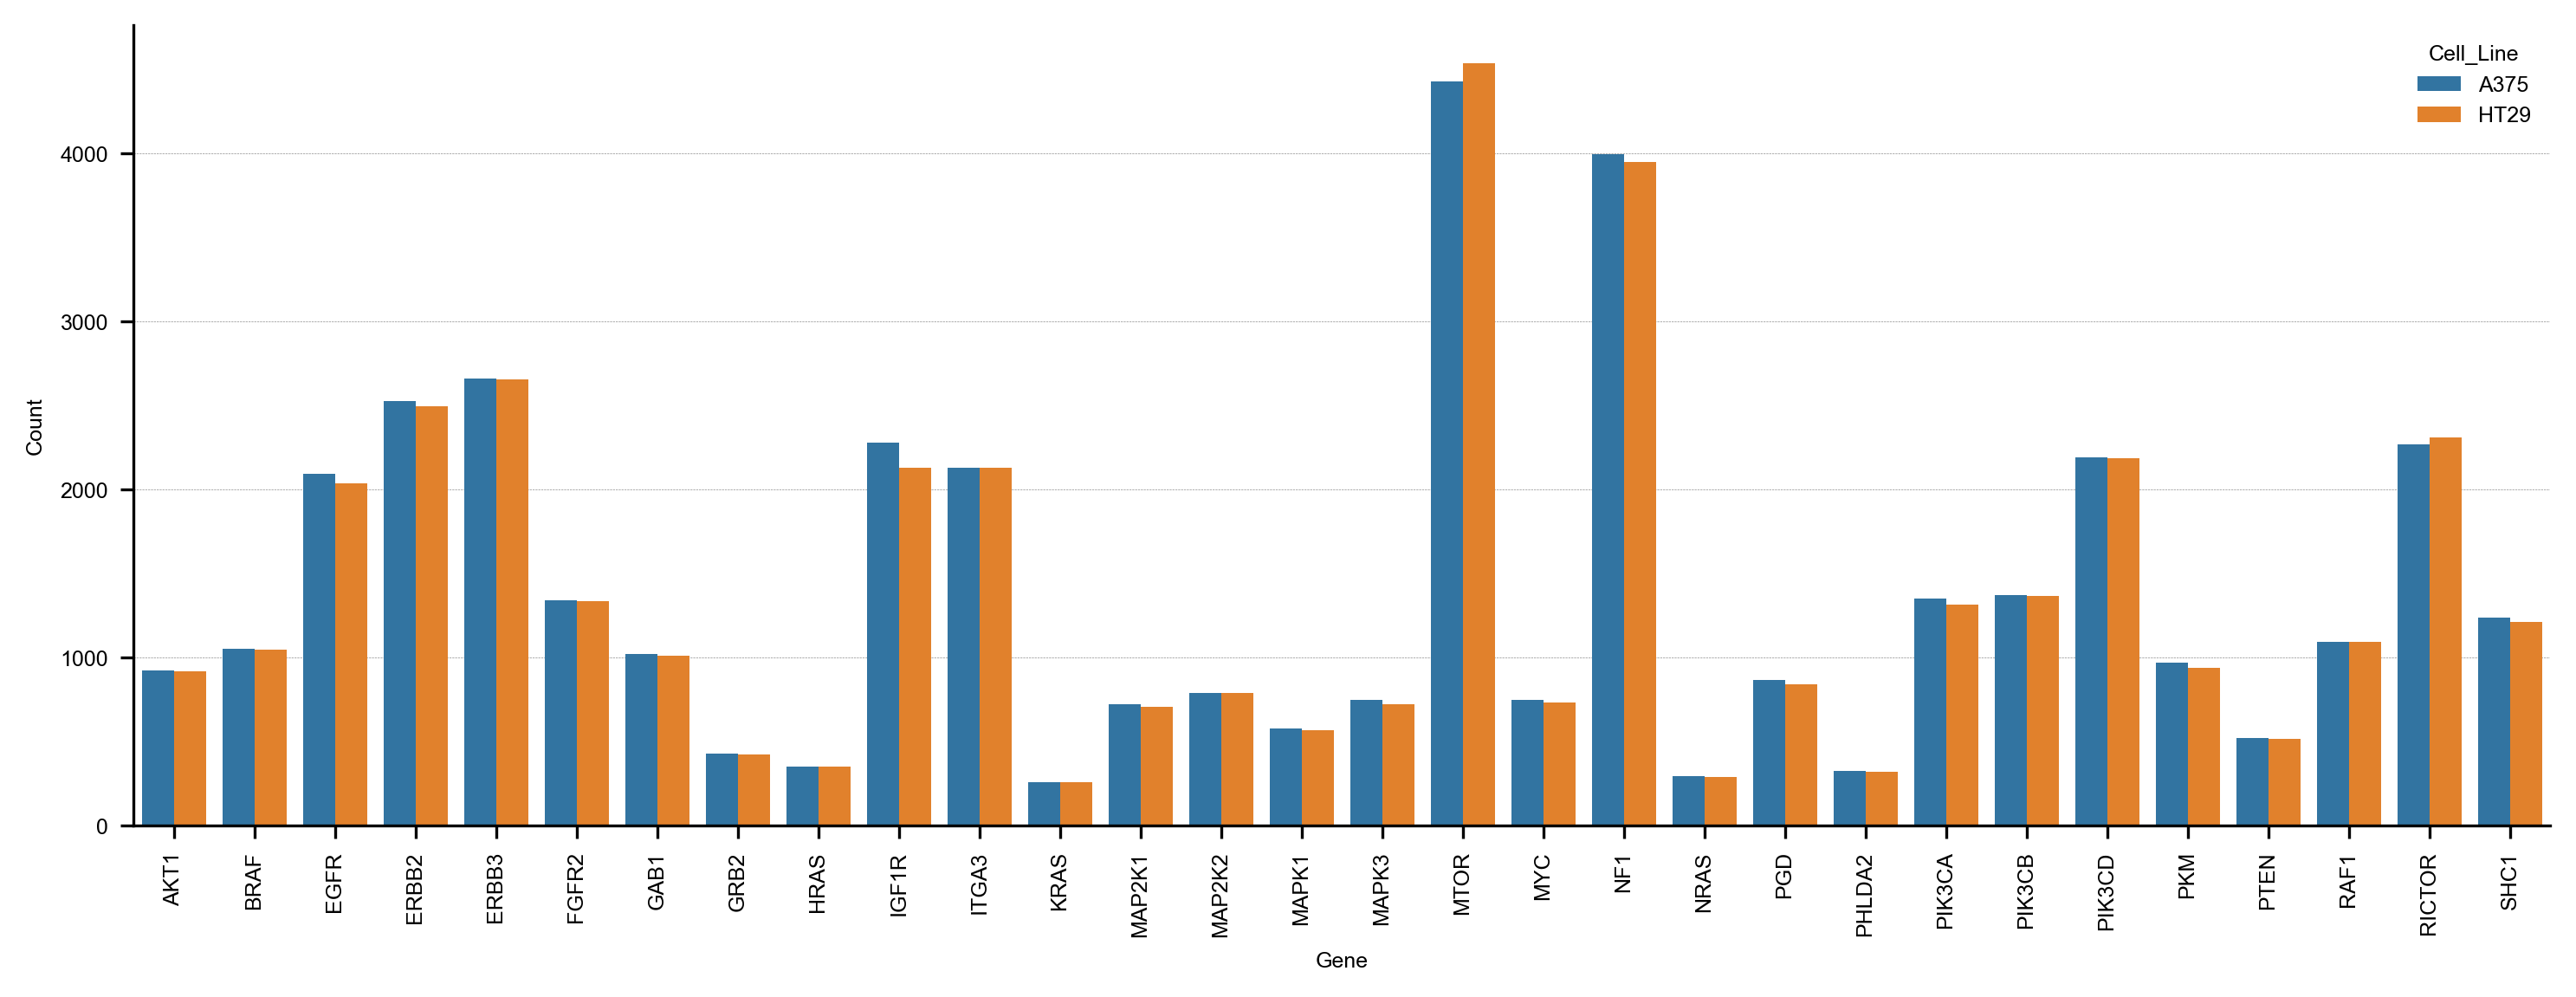

In [31]:
counts_before_DS = (
    annotated_variants_df
    .groupby(["Cell_Line", "Gene", "Class"])
    .size()
    .reset_index(name="Count")
)

counts_non_hits_before_DS = counts_before_DS[counts_before_DS["Class"] == "Neutral"]

plt.figure(figsize=(12,4))
sns.barplot(
    data=counts_non_hits_before_DS,
    x="Gene", y="Count", hue='Cell_Line', errorbar=None
)

plt.xticks(rotation=90)
plt.show()

### Stratified Downsampling

In [32]:
def stratified_downsampling(df, class_col, random_state=None):
    #Infer majority class + target size (length of the second largest class)
    class_counts = df[class_col].value_counts()
    majority_class = class_counts.idxmax()
    target_size = class_counts.nlargest(2).iloc[-1]

    #Separate majority class and other classes
    major_df = df[df[class_col] == majority_class]
    other_df = df[df[class_col] != majority_class]

    # If majority already not bigger than target, nothing to do
    if len(major_df) <= target_size:
        return df.copy()
    
    #Compute distribution of the majority df across Cell_Line and Gene
    major_distribution = (
        major_df
        .groupby(['Cell_Line', 'Gene'])
        .size()
        .reset_index(name='Count')
    )

    # Calculate proportions
    major_distribution['Proportion'] = major_distribution['Count'] / major_distribution['Count'].sum()

    # Determine number of samples to select from each Cell_Line × Gene group
    major_distribution['Target'] = np.floor(major_distribution['Proportion'] * target_size).astype(int)

    # Adjust target to ensure total matches target size 
    # i.e., distribute the remaining samples to the groups with the largest fractional remainders
    difference = target_size - major_distribution['Target'].sum()
    if difference > 0:
        fractional_parts = major_distribution['Proportion'] * target_size - major_distribution['Target']
        top_idx = fractional_parts.nlargest(difference).index
        major_distribution.loc[top_idx, 'Target'] += 1

    #Perform stratified downsampling
    downsampled_major_dfs= []
    for _, row in major_distribution.iterrows():
        cell_line = row['Cell_Line']
        gene = row['Gene']
        target = row['Target']

        subset = major_df[(major_df['Cell_Line'] == cell_line) & (major_df['Gene'] == gene)]

        if target > 0:
            n_sampled = min(target, len(subset)) # in case it is a very small group - but can lead to less samples than target_size overall
            downsampled_major_dfs.append(subset.sample(n=n_sampled, random_state=random_state))
    
    #Keep the indices until after the Top up step
    downsampled_majority_class_df = pd.concat(downsampled_major_dfs, axis=0)

    #Top up if needed (if very small groups caused total to be less than target_size)
    current_size = len(downsampled_majority_class_df)
    missing = target_size - current_size

    if missing>0: #ask supervisor if this is really needed
        remaining_samples = major_df.loc[~major_df.index.isin(downsampled_majority_class_df.index)]
        assert not remaining_samples.empty, ("Logic error: remaining_samples is empty but target_size not reached.")
        extra_n= min(missing, len(remaining_samples))
        extra_samples = remaining_samples.sample(n=extra_n, random_state=random_state)

        #Random subsample from the remaining samples now
        downsampled_majority_class_df = pd.concat([downsampled_majority_class_df, extra_samples], axis=0)

    # Reset index only at the end
    downsampled_majority_class_df = downsampled_majority_class_df.reset_index(drop=True)

    #Combine downsampled majority class with other classes
    balanced_df = pd.concat([downsampled_majority_class_df, other_df], ignore_index=True)

    return balanced_df

In [33]:
#Balanced Dataset
annotated_variants_df_balanced = stratified_downsampling(annotated_variants_df,class_col='Class', random_state=1)

In [34]:
print("Final class counts:")
print(annotated_variants_df_balanced["Class"].value_counts())

Final class counts:
Class
Neutral        788
Resistance     788
Sensitivity    451
Name: count, dtype: int64


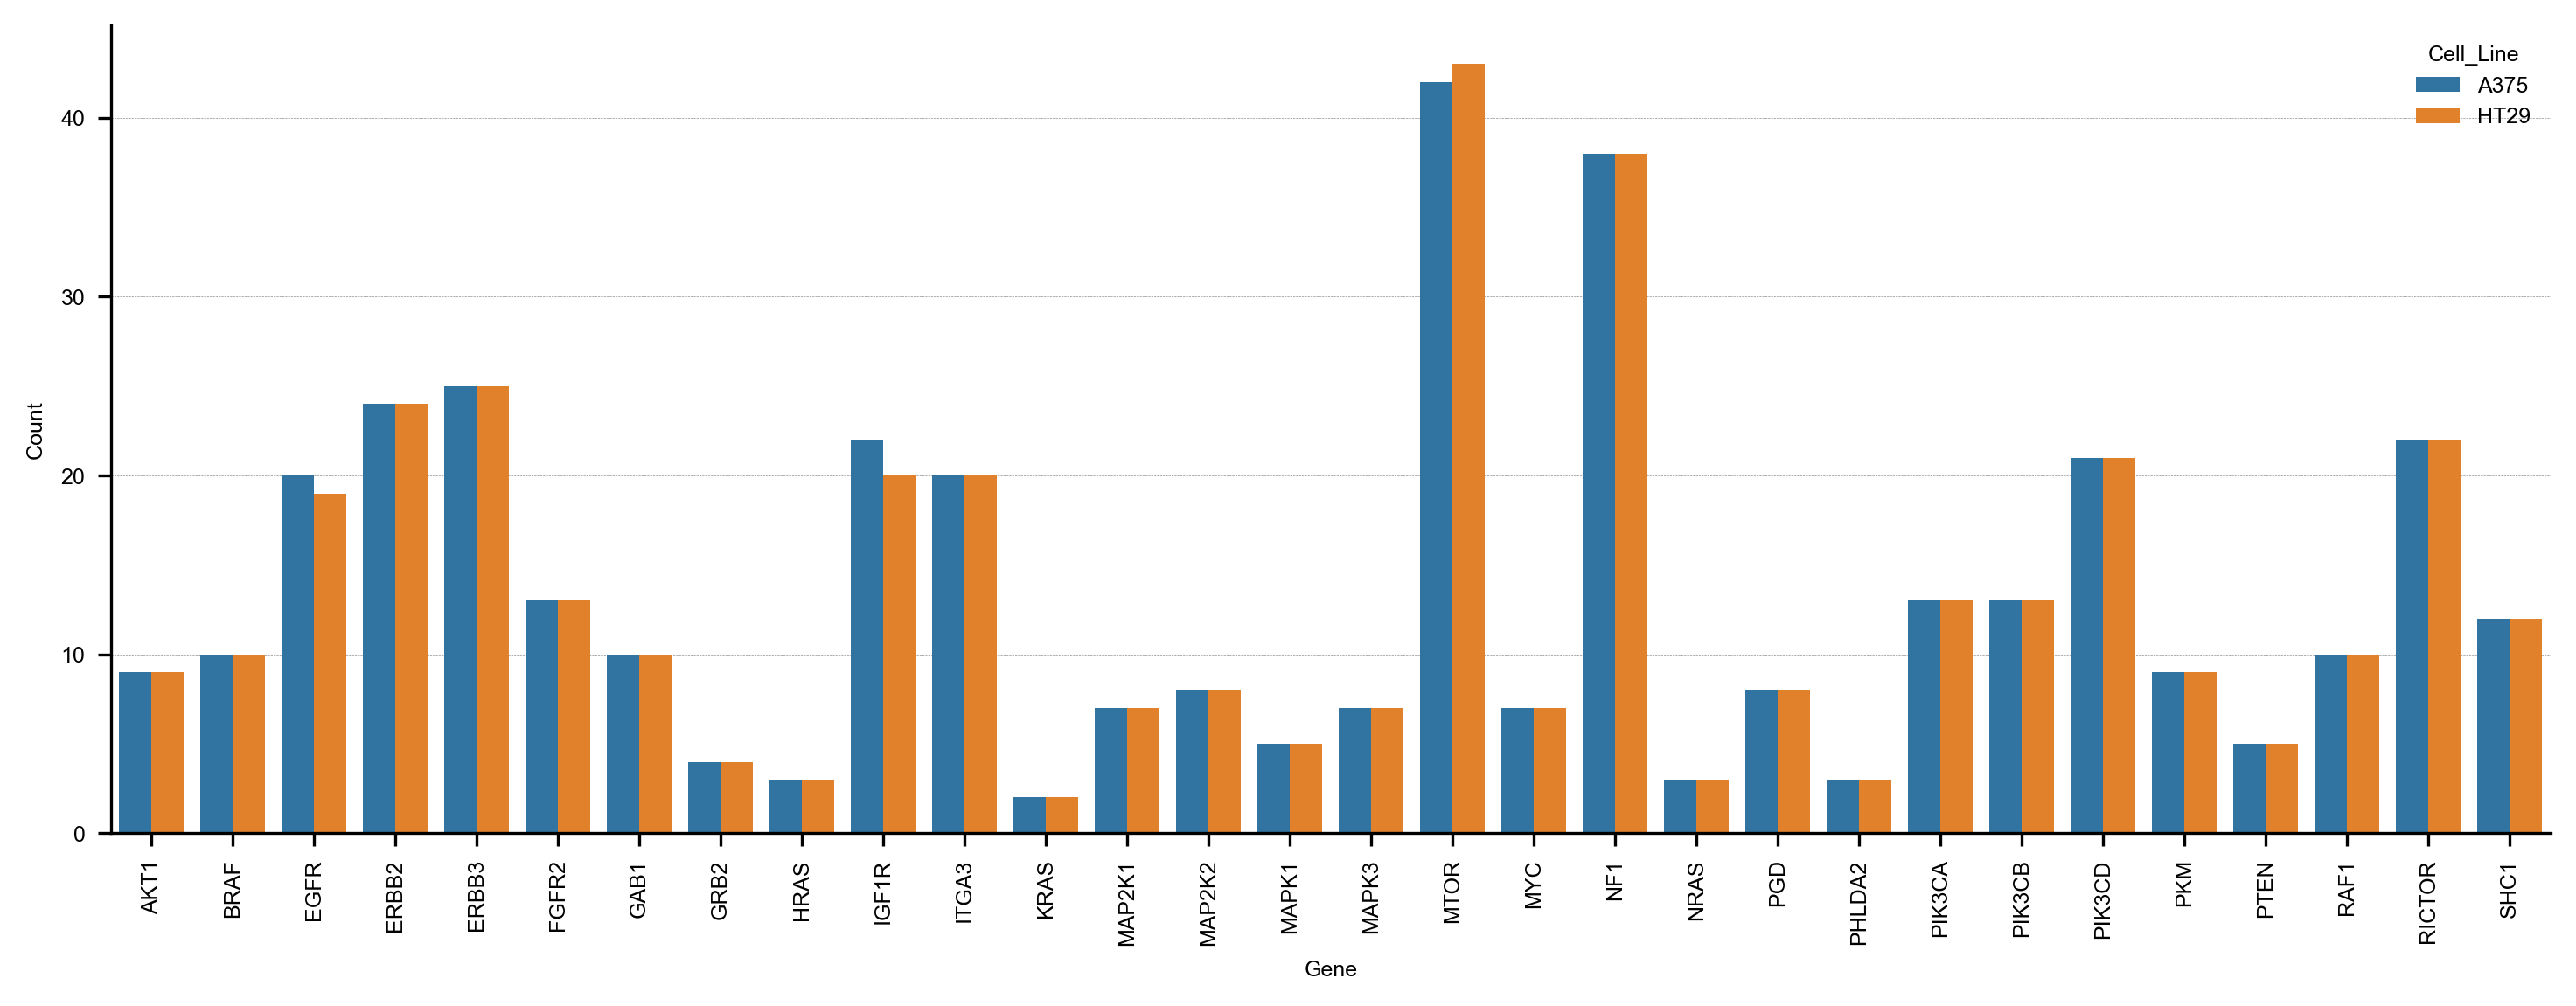

In [35]:
#Check distribution of non-hits after downsampling

counts_after_DS = (
    annotated_variants_df_balanced
    .groupby(["Cell_Line", "Gene", "Class"])
    .size()
    .reset_index(name="Count")
)

counts_non_hits_after_DS = counts_after_DS[counts_after_DS["Class"] == "Neutral"]

plt.figure(figsize=(12,4))
sns.barplot(
    data=counts_non_hits_after_DS,
    x="Gene", y="Count", hue="Cell_Line", errorbar=None
)

plt.xticks(rotation=90)
plt.show()

In [36]:
# Compute proportions within each group (Cell_Line × Gene)
prop_before = counts_non_hits_before_DS.copy()
prop_before["Proportion_before_DS"] = round(prop_before["Count"] / prop_before["Count"].sum(),4)
prop_before = prop_before[["Cell_Line", "Gene", "Proportion_before_DS"]]

prop_after = counts_non_hits_after_DS.copy()
prop_after["Proportion_after_DS"] = round(prop_after["Count"] / prop_after["Count"].sum(), 4)
prop_after = prop_after[["Cell_Line", "Gene", "Proportion_after_DS"]]


prop_compare = pd.merge(prop_before, prop_after,
                        on=["Cell_Line", "Gene"], how="inner")

# Correlation of proportions
corr = prop_compare["Proportion_before_DS"].corr(prop_compare["Proportion_after_DS"])

print("Correlation of per-group proportions (before vs after downsampling):", round(corr, 4))
print("\nProportion comparison (first 10 rows):")
print(prop_compare.head(10))

Correlation of per-group proportions (before vs after downsampling): 0.9996

Proportion comparison (first 10 rows):
  Cell_Line   Gene  Proportion_before_DS  Proportion_after_DS
0      A375   AKT1                0.0112               0.0114
1      A375   BRAF                0.0127               0.0127
2      A375   EGFR                0.0253               0.0254
3      A375  ERBB2                0.0305               0.0305
4      A375  ERBB3                0.0321               0.0317
5      A375  FGFR2                0.0162               0.0165
6      A375   GAB1                0.0123               0.0127
7      A375   GRB2                0.0052               0.0051
8      A375   HRAS                0.0043               0.0038
9      A375  IGF1R                0.0276               0.0279


# Constant Predictor

In [84]:
y_true = annotated_variants_df['Class_encoded']

In [85]:
#Constant prediction
neutral_class = le.transform(["Neutral"])[0]
sensitivity_class = le.transform(["Sensitivity"])[0]
resistance_class = le.transform(["Resistance"])[0]

In [86]:
y_pred = np.full(len(y_true), resistance_class)

In [87]:
y_pred[:5]

array([1, 1, 1, 1, 1])

In [88]:
len(y_true),len(y_pred)

(84024, 84024)

In [89]:
#Classification report

report = classification_report(
    y_true,
    y_pred,
    target_names=le.classes_,
    output_dict=True,
    zero_division=0
)

cm = confusion_matrix(y_true, y_pred)

print(report)
print(cm)

{'Neutral': {'precision': 0.0, 'recall': 0.0, 'f1-score': 0.0, 'support': 82785.0}, 'Resistance': {'precision': 0.009378272874416834, 'recall': 1.0, 'f1-score': 0.018582276093005706, 'support': 788.0}, 'Sensitivity': {'precision': 0.0, 'recall': 0.0, 'f1-score': 0.0, 'support': 451.0}, 'accuracy': 0.009378272874416834, 'macro avg': {'precision': 0.0031260909581389447, 'recall': 0.3333333333333333, 'f1-score': 0.006194092031001902, 'support': 84024.0}, 'weighted avg': {'precision': 8.795200210702258e-05, 'recall': 0.009378272874416834, 'f1-score': 0.00017426965582795982, 'support': 84024.0}}
[[    0 82785     0]
 [    0   788     0]
 [    0   451     0]]


In [90]:
metrics = {}

metrics["accuracy"] = report["accuracy"]

for avg_key in ["macro avg", "weighted avg"]:
    metrics[f"precision_{avg_key}"] = report[avg_key]["precision"]
    metrics[f"recall_{avg_key}"] = report[avg_key]["recall"]
    metrics[f"f1_{avg_key}"] = report[avg_key]["f1-score"]

print(metrics)

{'accuracy': 0.009378272874416834, 'precision_macro avg': 0.0031260909581389447, 'recall_macro avg': 0.3333333333333333, 'f1_macro avg': 0.006194092031001902, 'precision_weighted avg': 8.795200210702258e-05, 'recall_weighted avg': 0.009378272874416834, 'f1_weighted avg': 0.00017426965582795982}


In [91]:
print("=== Constant Baseline Metrics ===\n")

# Global metrics
print(f"accuracy              : {report['accuracy']:.3f}")

# Macro / weighted averages
for avg_key in ["macro avg", "weighted avg"]:

    print(
        f"precision_{avg_key:13}: "
        f"{report[avg_key]['precision']:.3f}"
    )

    print(
        f"recall_{avg_key:16}: "
        f"{report[avg_key]['recall']:.3f}"
    )

    print(
        f"f1_{avg_key:20}: "
        f"{report[avg_key]['f1-score']:.3f}"
    )

print("\n=== Class-wise Metrics ===\n")

# Per-class metrics
for cname in le.classes_:

    print(
        f"{cname:12} precision : "
        f"{report[cname]['precision']:.3f}"
    )

    print(
        f"{cname:12} recall    : "
        f"{report[cname]['recall']:.3f}"
    )

    print(
        f"{cname:12} f1        : "
        f"{report[cname]['f1-score']:.3f}"
    )

=== Constant Baseline Metrics ===

accuracy              : 0.009
precision_macro avg    : 0.003
recall_macro avg       : 0.333
f1_macro avg           : 0.006
precision_weighted avg : 0.000
recall_weighted avg    : 0.009
f1_weighted avg        : 0.000

=== Class-wise Metrics ===

Neutral      precision : 0.000
Neutral      recall    : 0.000
Neutral      f1        : 0.000
Resistance   precision : 0.009
Resistance   recall    : 1.000
Resistance   f1        : 0.019
Sensitivity  precision : 0.000
Sensitivity  recall    : 0.000
Sensitivity  f1        : 0.000


# Random Classifier

In [92]:
y_true = annotated_variants_df_balanced["Class_encoded"].values
class_ids = np.arange(len(le.classes_))

n_runs = 30

all_metrics = []
all_cms = []

for i in range(n_runs):

    rng = np.random.default_rng(i)

    # Random predictions (uniform across classes)
    y_pred = rng.choice(class_ids, size=len(y_true))

    # Metrics
    report = classification_report(
        y_true,
        y_pred,
        target_names=le.classes_,
        output_dict=True,
        zero_division=0
    )

    metrics = {
        "accuracy": report["accuracy"],
        "precision_macro avg": report["macro avg"]["precision"],
        "recall_macro avg": report["macro avg"]["recall"],
        "f1_macro avg": report["macro avg"]["f1-score"],
        "precision_weighted avg": report["weighted avg"]["precision"],
        "recall_weighted avg": report["weighted avg"]["recall"],
        "f1_weighted avg": report["weighted avg"]["f1-score"],
    }

    # Per-class metrics
    for cname in le.classes_:
        metrics[f"precision_{cname}"] = report[cname]["precision"]
        metrics[f"recall_{cname}"] = report[cname]["recall"]
        metrics[f"f1_{cname}"] = report[cname]["f1-score"]

    all_metrics.append(metrics)

    cm = confusion_matrix(y_true, y_pred, labels=class_ids)
    all_cms.append(cm)

# Aggregate results
metrics_df = pd.DataFrame(all_metrics)

metrics_mean = metrics_df.mean()
metrics_std = metrics_df.std()

print("=== Random Baseline Metrics (mean ± std) ===\n")

for key in metrics_mean.index:
    print(f"{key:25}: {metrics_mean[key]:.3f} ± {metrics_std[key]:.3f}")

=== Random Baseline Metrics (mean ± std) ===

accuracy                 : 0.331 ± 0.009
precision_macro avg      : 0.332 ± 0.009
recall_macro avg         : 0.331 ± 0.010
f1_macro avg             : 0.326 ± 0.009
precision_weighted avg   : 0.351 ± 0.009
recall_weighted avg      : 0.331 ± 0.009
f1_weighted avg          : 0.337 ± 0.008
precision_Neutral        : 0.387 ± 0.011
recall_Neutral           : 0.330 ± 0.013
f1_Neutral               : 0.356 ± 0.012
precision_Resistance     : 0.389 ± 0.013
recall_Resistance        : 0.332 ± 0.015
f1_Resistance            : 0.358 ± 0.013
precision_Sensitivity    : 0.220 ± 0.015
recall_Sensitivity       : 0.332 ± 0.024
f1_Sensitivity           : 0.264 ± 0.018


In [94]:
from sklearn.dummy import DummyClassifier



y_true = annotated_variants_df_balanced["Class_encoded"].values


X_dummy = np.zeros((len(y_true), 1))

n_runs = 30

all_metrics = []
all_cms = []

for i in range(n_runs):

    # Random baseline
    dummy = DummyClassifier(
        strategy="uniform",
        random_state=i
    )

    dummy.fit(X_dummy, y_true)

    y_pred = dummy.predict(X_dummy)

    # Metrics
    report = classification_report(
        y_true,
        y_pred,
        target_names=le.classes_,
        output_dict=True,
        zero_division=0
    )

    metrics = {
        "accuracy": report["accuracy"],
        "precision_macro avg": report["macro avg"]["precision"],
        "recall_macro avg": report["macro avg"]["recall"],
        "f1_macro avg": report["macro avg"]["f1-score"],
        "precision_weighted avg": report["weighted avg"]["precision"],
        "recall_weighted avg": report["weighted avg"]["recall"],
        "f1_weighted avg": report["weighted avg"]["f1-score"],
    }

    # Per-class metrics
    for cname in le.classes_:
        metrics[f"precision_{cname}"] = report[cname]["precision"]
        metrics[f"recall_{cname}"] = report[cname]["recall"]
        metrics[f"f1_{cname}"] = report[cname]["f1-score"]

    all_metrics.append(metrics)

    cm = confusion_matrix(
        y_true,
        y_pred,
        labels=np.arange(len(le.classes_))
    )

    all_cms.append(cm)

# Aggregate results
metrics_df = pd.DataFrame(all_metrics)

metrics_mean = metrics_df.mean()
metrics_std = metrics_df.std()

print("=== Random Baseline Metrics (mean ± std) ===\n")

for k in [
    "accuracy",
    "precision_macro avg",
    "recall_macro avg",
    "f1_macro avg",
    "precision_weighted avg",
    "recall_weighted avg",
    "f1_weighted avg"
]:
    print(
        f"{k:25}: "
        f"{metrics_mean[k]:.3f} ± {metrics_std[k]:.3f}"
    )

print("\n=== Class-wise Metrics (mean ± std) ===\n")

for cname in le.classes_:

    for metric in ["precision", "recall", "f1"]:

        key = f"{metric}_{cname}"

        print(
            f"{cname:12} {metric:10}: "
            f"{metrics_mean[key]:.3f} ± {metrics_std[key]:.3f}"
        )

=== Random Baseline Metrics (mean ± std) ===

accuracy                 : 0.333 ± 0.009
precision_macro avg      : 0.333 ± 0.009
recall_macro avg         : 0.333 ± 0.009
f1_macro avg             : 0.328 ± 0.009
precision_weighted avg   : 0.351 ± 0.009
recall_weighted avg      : 0.333 ± 0.009
f1_weighted avg          : 0.338 ± 0.009

=== Class-wise Metrics (mean ± std) ===

Neutral      precision : 0.391 ± 0.015
Neutral      recall    : 0.335 ± 0.016
Neutral      f1        : 0.361 ± 0.015
Resistance   precision : 0.386 ± 0.013
Resistance   recall    : 0.329 ± 0.017
Resistance   f1        : 0.355 ± 0.014
Sensitivity  precision : 0.223 ± 0.010
Sensitivity  recall    : 0.335 ± 0.019
Sensitivity  f1        : 0.268 ± 0.013


In [93]:
print("=== Random Baseline Metrics (mean ± std) ===\n")

# Global metrics
for k in [
    "accuracy",
    "precision_macro avg",
    "recall_macro avg",
    "f1_macro avg",
    "precision_weighted avg",
    "recall_weighted avg",
    "f1_weighted avg"
]:
    print(
        f"{k:25}: "
        f"{metrics_mean[k]:.3f} ± {metrics_std[k]:.3f}"
    )

print("\n=== Class-wise Metrics (mean ± std) ===\n")

# Class-wise metrics
for cname in le.classes_:

    for metric in ["precision", "recall", "f1"]:

        key = f"{metric}_{cname}"

        print(
            f"{cname:12} {metric:10}: "
            f"{metrics_mean[key]:.3f} ± {metrics_std[key]:.3f}"
        )

=== Random Baseline Metrics (mean ± std) ===

accuracy                 : 0.331 ± 0.009
precision_macro avg      : 0.332 ± 0.009
recall_macro avg         : 0.331 ± 0.010
f1_macro avg             : 0.326 ± 0.009
precision_weighted avg   : 0.351 ± 0.009
recall_weighted avg      : 0.331 ± 0.009
f1_weighted avg          : 0.337 ± 0.008

=== Class-wise Metrics (mean ± std) ===

Neutral      precision : 0.387 ± 0.011
Neutral      recall    : 0.330 ± 0.013
Neutral      f1        : 0.356 ± 0.012
Resistance   precision : 0.389 ± 0.013
Resistance   recall    : 0.332 ± 0.015
Resistance   f1        : 0.358 ± 0.013
Sensitivity  precision : 0.220 ± 0.015
Sensitivity  recall    : 0.332 ± 0.024
Sensitivity  f1        : 0.264 ± 0.018
